In [41]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [9]:
df = pd.read_csv("D:\\projects internship\\Gncipl\\Project_3\\battery_dataset.csv")


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BatteryID           2000 non-null   object 
 1   BatchID             2000 non-null   object 
 2   Cycle               2000 non-null   int64  
 3   Voltage             2000 non-null   float64
 4   Current             2000 non-null   float64
 5   Temperature         2000 non-null   float64
 6   ChargeTime          2000 non-null   float64
 7   DischargeTime       2000 non-null   float64
 8   InternalResistance  2000 non-null   float64
 9   Capacity            2000 non-null   float64
 10  AmbientHumidity     2000 non-null   float64
 11  C_Rate              2000 non-null   float64
 12  SOH                 2000 non-null   float64
dtypes: float64(10), int64(1), object(2)
memory usage: 203.3+ KB


In [13]:
df.isnull().sum()

BatteryID             0
BatchID               0
Cycle                 0
Voltage               0
Current               0
Temperature           0
ChargeTime            0
DischargeTime         0
InternalResistance    0
Capacity              0
AmbientHumidity       0
C_Rate                0
SOH                   0
dtype: int64

In [14]:
df.head()

,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179


In [15]:
df.describe()

,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,3.592491,1.236696,25.281789,74.094272,75.210691,0.149986,1.999961,50.483573,1.264644,61.293052
std,577.494589,0.346469,0.428394,4.902033,25.482926,25.795982,0.057751,0.289359,11.328639,0.434534,18.481668
min,1.000000,3.000289,0.500046,9.902439,30.004754,30.021679,0.046516,1.460427,30.034148,0.500917,27.791377
25%,500.750000,3.291341,0.871196,21.952101,52.697757,52.858818,0.100005,1.752301,40.942929,0.901011,45.290571
50%,1000.500000,3.585221,1.223112,25.238242,73.803345,75.158765,0.149887,2.001169,50.940957,1.259172,61.085327
75%,1500.250000,3.893895,1.605997,28.464827,95.252876,97.675132,0.200170,2.252186,59.951592,1.639257,76.830696
max,2000.000000,4.199353,1.999337,40.965538,119.875559,119.970588,0.251932,2.521192,69.965983,1.999807,100.000000


In [16]:
df.groupby("BatchID")["Capacity"].mean()


BatchID
BatchA    1.991680
BatchB    1.985270
BatchC    1.990431
BatchD    2.033097
Name: Capacity, dtype: float64

In [17]:
df.groupby("Cycle")["SOH"].mean().sort_index()


Cycle
1       100.000000
2        99.415837
3        97.695097
4        97.623562
5        98.018179
           ...    
1996     32.424118
1997     29.909219
1998     30.458467
1999     30.965351
2000     30.882735
Name: SOH, Length: 2000, dtype: float64

In [18]:
df.groupby("C_Rate")["Capacity"].agg(["mean", "count"])


,mean,count
C_Rate,,
0.500917,2.323455,1
0.501498,2.034376,1
0.503121,2.290326,1
0.503783,1.626710,1
0.505044,2.003062,1
...,...,...
1.997378,2.021735,1
1.998041,2.261102,1
1.998239,2.064612,1


In [19]:
df[["BatteryID", "Capacity", "SOH"]].sort_values("Capacity", ascending=False).head(5)


,BatteryID,Capacity,SOH
51,BAT0052,2.521192,91.460998
52,BAT0053,2.518880,91.261461
6,BAT0007,2.518359,97.305206
7,BAT0008,2.515409,97.925826
12,BAT0013,2.514716,94.937465


In [20]:
df.groupby("BatchID")[["ChargeTime", "DischargeTime"]].mean()


,ChargeTime,DischargeTime
BatchID,,
BatchA,74.368177,76.163203
BatchB,73.844974,75.159529
BatchC,74.232131,73.755545
BatchD,73.913857,75.698736


In [21]:
df[["InternalResistance", "Capacity"]].sort_values("InternalResistance")


,InternalResistance,Capacity
8,0.046516,2.503767
9,0.048156,2.496092
22,0.049254,2.492107
1,0.049553,2.491344
15,0.049971,2.470281
...,...,...
1969,0.250461,1.507579
1994,0.250544,1.465468
1992,0.250657,1.510667
1977,0.251009,1.549852


In [22]:
df.loc[df["SOH"] < 80, ["BatteryID", "BatchID", "Cycle", "SOH", "Capacity"]].sort_values("SOH")


,BatteryID,BatchID,Cycle,SOH,Capacity
1954,BAT1955,BatchC,1955,27.791377,1.570469
1950,BAT1951,BatchD,1951,28.821618,1.533789
1988,BAT1989,BatchC,1989,29.049009,1.510778
1976,BAT1977,BatchC,1977,29.138644,1.495446
1986,BAT1987,BatchB,1987,29.429177,1.508483
...,...,...,...,...,...
366,BAT0367,BatchB,367,79.911584,2.290925
387,BAT0388,BatchC,388,79.928040,2.297319
438,BAT0439,BatchC,439,79.936006,2.305561
406,BAT0407,BatchB,407,79.939400,2.313379


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BatteryID           2000 non-null   object 
 1   BatchID             2000 non-null   object 
 2   Cycle               2000 non-null   int64  
 3   Voltage             2000 non-null   float64
 4   Current             2000 non-null   float64
 5   Temperature         2000 non-null   float64
 6   ChargeTime          2000 non-null   float64
 7   DischargeTime       2000 non-null   float64
 8   InternalResistance  2000 non-null   float64
 9   Capacity            2000 non-null   float64
 10  AmbientHumidity     2000 non-null   float64
 11  C_Rate              2000 non-null   float64
 12  SOH                 2000 non-null   float64
dtypes: float64(10), int64(1), object(2)
memory usage: 203.3+ KB


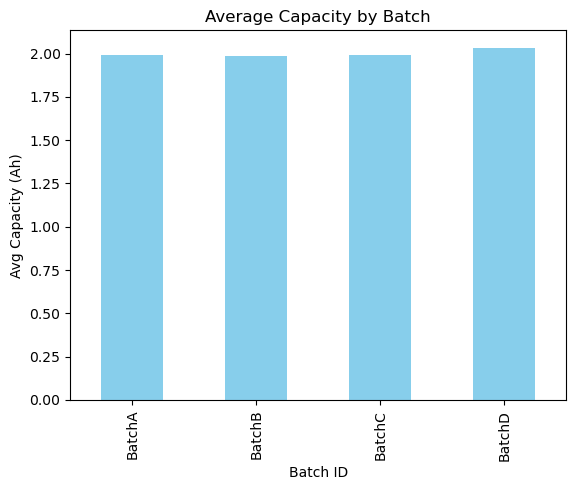

In [45]:
avg_capacity = df.groupby("BatchID")["Capacity"].mean()

avg_capacity.plot(kind="bar", color="skyblue", title="Average Capacity by Batch")
plt.xlabel("Batch ID")
plt.ylabel("Avg Capacity (Ah)")
plt.show()


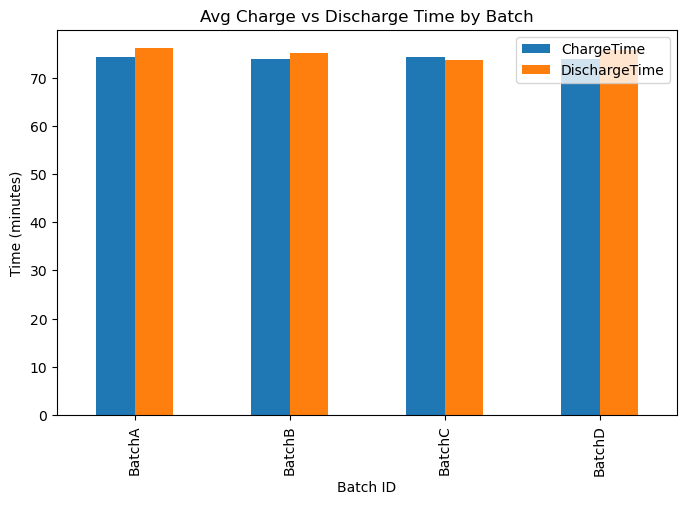

In [44]:
avg_times = df.groupby("BatchID")[["ChargeTime", "DischargeTime"]].mean()

avg_times.plot(kind="bar", figsize=(8,5))
plt.title("Avg Charge vs Discharge Time by Batch")
plt.xlabel("Batch ID")
plt.ylabel("Time (minutes)")
plt.show()
